In [1]:
import scrape_nbadraft_net
import matplotlib.pyplot as plt
import pandas as pd

c:\code\better_comps\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
base_df = scrape_nbadraft_net.build_df(get_text=True)

## Is this site better at predicting NBA success than draft order?

### Look at overall rating vs games played.

we need to restrict to players who actually made the NBA.

I don't think I've got actual draft position in this df right now.

In [5]:
df = base_df[~base_df.g.isna()].copy()

In [4]:
df.loc[df.overall.idxmin()]

nbadraft_net_comps                                        [Justin Reed]
descr_other           [Overall: Dawson is undoubtedly a tweener forw...
descr_strengths       [Dawson, when on his game, is a physical prese...
descr_weaknesses      [Intensity and motor seem to vary even within ...
descr_raw             <div class="vc_tta-panel vc_active" data-vc-co...
Athleticism                                                         8.0
Size                                                                6.0
Defense                                                             7.0
Strength                                                            7.0
Quickness                                                           7.0
Leadership                                                          8.0
Jump Shot                                                           6.0
NBA Ready                                                           8.0
Rebounding                                                      

In [22]:
df.mock.describe()

count    724.000000
mean      25.941989
std       15.832262
min        1.000000
25%       12.000000
50%       25.000000
75%       38.000000
max       60.000000
Name: mock, dtype: float64

Text(0, 0.5, 'nbadraft.net mock draft')

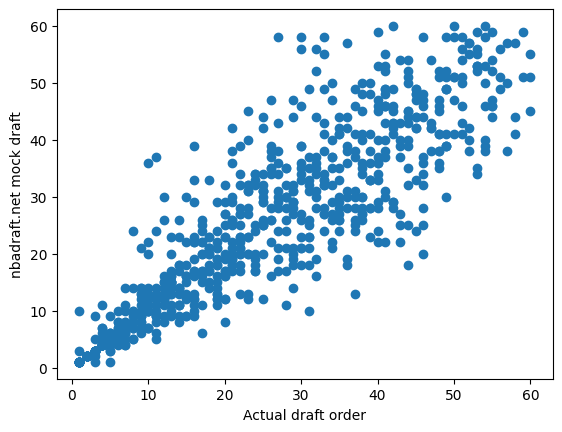

In [13]:
plt.scatter(df.draft_order, df.mock)
plt.xlabel("Actual draft order")
plt.ylabel("nbadraft.net mock draft")

I'm going to throw out outliers

In [14]:
df2 = df[df.mp > 500].copy()

In [15]:
df2.g.corr(df2.draft_order)

np.float64(-0.2776501806976974)

mock draft order is a slightly worse predictor than actual draft order as far as games played.

In [16]:
df2.g.corr(df2.mock)

np.float64(-0.22010395693743964)

## look at 

vorp, per in this dataset are median season-level values.

I was trying to find good metrics that aren't affected by injury. draft scouts aren't trying to predict injuries, so it's worth looking at other measures that capture how good a player was that isn't dependent on career longevity.

mock draft order is slightly worse at predicting PER, as well

In [17]:
df2.per.corr(df2.draft_order)

np.float64(-0.2729385144511493)

In [18]:
df2.per.corr(df2.mock)

np.float64(-0.26983005866078086)

In [20]:
df2['ws'] = df.ows + df2.dws

this is true of win shares, as well

In [22]:
df2.ws.corr(df2.draft_order)

np.float64(-0.25890790187467727)

In [21]:
df2.ws.corr(df2.mock)

np.float64(-0.21392236004446108)

PER is a little biased to big men, IMO

Text(0, 0.5, 'median PER')

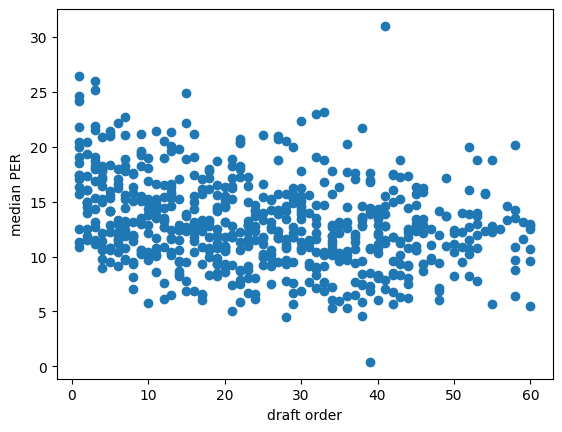

In [23]:
plt.scatter(df2.draft_order, df2.per)
plt.xlabel("draft order")
plt.ylabel("median PER")

In [27]:
df2[df2.per > 20]

,nbadraft_net_comps,descr_other,descr_strengths,descr_weaknesses,descr_raw,Athleticism,Size,Defense,Strength,Quickness,...,mp,ows,dws,player_ascii_x,player_y,draft_position,draft_year,draft_order,player_ascii_y,ws
34,"[Bobby Portis, Tom Gugliotta]",[Overall: Alperen Sengun is a beast and one of...,"[Physical center, with a lot of determination ...",[Average athlete by NBA standards … Small for ...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",7.0,7.0,7.0,8.0,7.0,...,9856.0,15.1,13.2,Alperen Sengun,Alperen Sengun,PF/C,2021.0,16.0,Alperen Sengun,28.3
39,"[Amar’e Stoudemire, DeAndre Jordan]",[],"[Physically gifted, Drummond’s combination of ...",[Drummond wasn’t featured on the block that mu...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",10.0,10.0,8.0,9.0,10.0,...,29646.0,32.7,57.8,Andre Drummond,Andre Drummond,PF/C,2012.0,9.0,Andre Drummond,90.5
53,"[Kevin Garnett, Marcus Camby]",[Outlook: Considered the top player in his cla...,"[Fluid athleticism, incredible length and guar...",[The number one drawback on Davis is his overa...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",10.0,10.0,10.0,6.0,9.0,...,29447.0,77.4,49.6,Anthony Davis,Anthony Davis,PF,2012.0,1.0,Anthony Davis,127.0
86,NaN,[ Notes: The consensus 2009 #1 pick. Griffin h...,[],[Could stand to work on a little bit of body c...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",10.0,8.0,8.0,10.0,8.0,...,27540.0,57.2,31.1,Blake Griffin,Blake Griffin,PF,2009.0,1.0,Blake Griffin,88.3
141,[Kristaps Porzingis],[Outlook: One of the rarest of players to come...,[Extremely skilled frontcourt player who can i...,[Lack of physical strength (195 lbs) remains h...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",8.0,9.0,9.0,6.0,7.0,...,4848.0,9.1,9.9,Chet Holmgren,Chet Holmgren,PF/C,2022.0,2.0,Chet Holmgren,19.0
158,"[Ian Mahinmi, Amir Johnson]",[Strenghts: Capela is as good as any athlete e...,[],[The biggest knock on Capela is his lack of ba...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",9.0,9.0,7.0,6.0,9.0,...,18032.0,45.3,26.5,Clint Capela,Clint Capela,PF/C,2014.0,25.0,Clint Capela,71.8
182,"[Jay Williams, Jerryd Bayless]",[Notes: Has really developed into a solid pro...,[Late blooming 6’2 PG with ideal size and stre...,[Not a true point guard … Looks for his own sh...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",8.0,8.0,7.0,8.0,9.0,...,32614.0,98.1,20.1,Damian Lillard,Damian Lillard,PG,2012.0,6.0,Damian Lillard,118.2
187,[Chris Andersen],[Outlook: Made a surprising decision to some t...,"[A long, fluid, bouncy bigman who runs the flo...",[A below average shooter … Lacks touch on his ...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",9.0,9.0,8.0,8.0,8.0,...,10991.0,30.0,14.8,Daniel Gafford,Daniel Gafford,PF/C,2019.0,38.0,Daniel Gafford,44.8
225,"[Eddy Curry, Benoit Benjamin]",[Overall: A true talent. You won’t find many g...,"[An extremely strong player, his body is well ...",[Cousins’ lack of maturity and mental focus is...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",8.0,10.0,7.0,9.0,6.0,...,23405.0,22.3,34.9,DeMarcus Cousins,DeMarcus Cousins,PF/C,2010.0,5.0,DeMarcus Cousins,57.2
256,"[Luis Scola, Marc Gasol]",[Notes: Son of 7-3 Lithuanian star Arvydas Sab...,"[High energy and passionate post player, who a...",[Average athlete … Below average wingspan for ...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",6.0,7.0,8.0,8.0,7.0,...,22599.0,50.8,27.4,Domantas Sabonis,Domantas Sabonis,PF/C,2016.0,11.0,Domantas Sabonis,78.2


oh crap, I think this is missing some players it should have eg Nikola Jokic. damn diacritics

Bogdan Bogdanović

In [13]:
import career_stats

In [14]:
stats = career_stats.get_career_stats()

In [15]:
sdf = pd.DataFrame(stats).reset_index()

In [16]:
import unidecode

In [11]:
df2[df2.draft_year == 2014].sort_values(by='draft_order')

,nbadraft_net_comps,descr_other,descr_strengths,descr_weaknesses,descr_raw,Athleticism,Size,Defense,Strength,Quickness,...,g,mp,ows,dws,player_ascii_x,player_y,draft_position,draft_year,draft_order,player_ascii_y
46,"[Vince Carter, Rudy Gay]",[Notes: Hype and expectations were enormous fo...,[Off the charts run/jump athleticism … Lateral...,[The biggest issue is whether or not Wiggins h...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",10.0,9.0,8.0,7.0,9.0,...,935.0,31302.0,21.0,22.1,Andrew Wiggins,Andrew Wiggins,SF,2014.0,1.0,Andrew Wiggins
380,[Carmelo Anthony],"[Notes: A Mormon, and has not yet done a Mormo...","[Parker is on another level from his peers, sk...",[Defense and position are the two biggest ques...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",8.0,9.0,6.0,9.0,8.0,...,425.0,11341.0,8.2,8.9,Jabari Parker,Jabari Parker,SF/PF,2014.0,2.0,Jabari Parker
479,"[Tim Duncan, Akeem Olajuwon]","[Notes: Embiid, whose father was a profession...",[The sculpted Embiid has a prototypical body f...,"[Embiid had trouble staying on the floor, eith...","<div class=""vc_tta-panel vc_active"" data-vc-co...",9.0,10.0,9.0,8.0,8.0,...,485.0,15436.0,41.5,26.9,Joel Embiid,Joel Embiid,C,2014.0,3.0,Joel Embiid
0,[Kenneth Faried],[Overall: Considered a high character guy … Go...,[A very athletic and versatile PF … Is a very ...,[Gordon’s main weaknesses revolve around his l...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",9.0,8.0,8.0,7.0,8.0,...,793.0,23102.0,28.7,22.6,Aaron Gordon,Aaron Gordon,PF,2014.0,4.0,Aaron Gordon
194,"[Penny Hardaway, Leandro Barbosa]",[Notes: Had a dominant performance for Austral...,[The 18-year-old Aussie is a fluid and versati...,[Level of competition is the biggest knock aga...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",8.0,9.0,8.0,7.0,9.0,...,355.0,6490.0,2.0,4.9,Dante Exum,Dante Exum,PG/SG,2014.0,5.0,Dante Exum
656,[Dwyane Wade],[Notes: Second-team All-American his freshman ...,"[Strong, heady point guard with great size and...",[Not a great outside shooter. Only made 29% f...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",7.0,8.0,7.0,9.0,7.0,...,718.0,20791.0,9.7,26.6,Marcus Smart,Marcus Smart,PG,2014.0,6.0,Marcus Smart
536,"[David Lee, Billy Owens]",[Notes: One of the most polarizing prospects o...,[Very strong upper body and a reliable left ha...,[Despite all the good things mentioned about h...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",8.0,8.0,7.0,9.0,8.0,...,770.0,24742.0,28.5,27.3,Julius Randle,Julius Randle,PF,2014.0,7.0,Julius Randle
729,[Jason Kapono],[Notes: The Canadian invasion continues … Big ...,[Pure shooter with a picture perfect stroke an...,[Although he’s viewed as more than just a shoo...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",7.0,8.0,7.0,7.0,7.0,...,460.0,8278.0,1.9,3.6,Nik Stauskas,Nik Stauskas,SG,2014.0,8.0,Nik Stauskas
742,"[Wayman Tisdale, Jamal Mashburn]","[Notes: Proved to be extremely clutch, knockin...",[Ideal PF size with very long arms and the ski...,[The same youth and inexperience that makes hi...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",8.0,9.0,8.0,8.0,8.0,...,452.0,7106.0,4.2,7.8,Noah Vonleh,Noah Vonleh,PF,2014.0,9.0,Noah Vonleh
281,"[Devin Harris, Rajon Rondo]",[Notes: Played for USA U19 team this past summ...,"[Tall, quick and talented offensive point guar...","[While his jumper isn’t horrible, he needs to ...","<div class=""vc_tta-panel vc_active"" data-vc-co...",8.0,9.0,8.0,6.0,9.0,...,611.0,16213.0,3.1,14.2,Elfrid Payton,Elfrid Payton,PG,2014.0,10.0,Elfrid Payton


In [18]:
df.per

0       15.20
1       11.55
2       10.55
4       12.20
5        8.80
        ...  
1009    12.20
1010     5.30
1011    41.15
1012     9.70
1013    24.65
Name: per, Length: 811, dtype: float64

In [19]:
df.per.describe()

count    811.000000
mean      11.912515
std        5.570313
min      -20.000000
25%        9.300000
50%       12.000000
75%       15.100000
max       41.150000
Name: per, dtype: float64

In [20]:
df[df.per < 0]

,nbadraft_net_comps,descr_other,descr_strengths,descr_weaknesses,descr_raw,Athleticism,Size,Defense,Strength,Quickness,...,vorp,per,g,mp,player_ascii_x,player_y,draft_position,draft_year,draft_order,player_ascii_y
47,[Matt Carroll],[],[Cerebral 2 guard most known for his range and...,"[He lacks athleticism, size and strength, whic...","<div class=""vc_tta-panel vc_active"" data-vc-co...",6.0,6.0,6.0,7.0,6.0,...,-0.10,-1.20,5.0,24.0,Andy Rautins,Andy Rautins,SG,2010.0,38.0,Andy Rautins
57,[Ante Tomic],"[Strenghts: He has an impressive frame at 7-2,...",[],"[Despite his frame, he still needs to add some...","<div class=""vc_tta-panel vc_active"" data-vc-co...",7.0,9.0,7.0,7.0,7.0,...,-0.25,-14.65,28.0,443.0,Anzejs Pasecniks,Anzejs Pasecniks,C,2017.0,25.0,Anzejs Pasecniks
62,[Bostjan Nachbar],[Overall: Arnoldas Kulboka is one of the best ...,[Great size for his position … Solid wingspan ...,"[Not as vestatile as you would expect, at leas...","<div class=""vc_tta-panel vc_active"" data-vc-co...",7.0,9.0,7.0,6.0,7.0,...,0.00,-10.70,2.0,5.0,Arnoldas Kulboka,Arnoldas Kulboka,SF,2018.0,55.0,Arnoldas Kulboka
75,[Sam Clancy],[Outlook: With more and more teams looking to ...,[Big bodied forward with aggressive scoring mi...,"[Undersized power forward (6’8""), though has a...","<div class=""vc_tta-panel vc_active"" data-vc-co...",7.0,7.0,7.0,9.0,7.0,...,-0.10,-17.60,3.0,10.0,Ben Bentil,Ben Bentil,PF,2016.0,51.0,Ben Bentil
195,[Chris Douglas-Roberts (less explosive)],[Borko Popic is a lead scout/contributor to NB...,"[A versatile lefty, he has the ability to play...","[A very inconsistent scorer, he goes through d...","<div class=""vc_tta-panel vc_active"" data-vc-co...",7.0,8.0,7.0,7.0,7.0,...,-0.10,-3.30,5.0,39.0,Darington Hobson,Darington Hobson,SF,2010.0,37.0,Darington Hobson
206,[Wade Baldwin],[Overall: Johnson’s productivity and spot up s...,[Johnson is a tall combo guard prospect who st...,[Doesn’t have many skills that project him bei...,"<div class=""vc_tta-panel vc_active"" data-vc-co...",8.0,8.0,7.0,7.0,8.0,...,0.00,-20.00,2.0,2.0,David Johnson,David Johnson,PG,2021.0,47.0,David Johnson
250,"[Kendrick Perkins, Nikola Jokic]","[Notes: Measured 6’10 (in shoes) 253 lbs, with...",[Smooth freshman big with nice combination of ...,"[Despite being very good at a young age, his u...","<div class=""vc_tta-panel vc_active"" data-vc-co...",6.0,9.0,7.0,9.0,7.0,...,-0.10,-1.20,7.0,24.0,Diamond Stone,Diamond Stone,C,2016.0,40.0,Diamond Stone
309,[Chris Wilcox],[],"[A strong, athletic and lengthy 6’9 forward (i...","[Right now, Lawal is raw and very limited offe...","<div class=""vc_tta-panel vc_active"" data-vc-co...",8.0,8.0,8.0,7.0,7.0,...,0.00,-9.10,1.0,2.0,Gani Lawal,Gani Lawal,PF,2010.0,46.0,Gani Lawal
576,[Anthony Parker],[],[Explosive scorer that possesses a wide offens...,"[Not a very strong finisher at the rim, due in...","<div class=""vc_tta-panel vc_active"" data-vc-co...",7.0,8.0,7.0,7.0,8.0,...,-0.20,-4.50,17.0,52.0,Kevin Murphy,Kevin Murphy,SG,2012.0,47.0,Kevin Murphy
679,[],"[Overall: Shulga is a mature, well-rounded com...",[Shulga stands at 6’5″ with a 6’6″ wingspan an...,"[Not an explosive athlete, vertical isn’t impr...","<div class=""vc_tta-panel vc_active"" data-vc-co...",7.0,7.0,7.0,7.0,7.0,...,0.00,-18.70,1.0,2.0,Max Shulga,Max Shulga,PG/SG,2025.0,57.0,Max Shulga


In [21]:
df.loc[830]

nbadraft_net_comps                          [Anthony Mason, Boris Diaw]
descr_other                                                          []
descr_strengths       [Super-intriguing prospect with lottery-level ...
descr_weaknesses      [Overall scoring ability is very unrefined, th...
descr_raw             <div class="vc_tta-panel vc_active" data-vc-co...
Athleticism                                                         8.0
Size                                                                8.0
Defense                                                             7.0
Strength                                                            9.0
Quickness                                                           8.0
Leadership                                                          7.0
Jump Shot                                                           6.0
NBA Ready                                                           8.0
Rebounding                                                      